In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.5 MB/s eta 0:00:00


**EXTRACTING DATASET ZIP FILE**

In [ ]:
import zipfile
import os

output_dir = "rock-paper-scissor-dataset"
os.makedirs(output_dir, exist_ok=True)
z = zipfile.ZipFile("/content/paper-rock-scissor.v1i.folder.zip")
z.extractall(output_dir)

**MODEL**

In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11m-cls.pt")

results = model.train(data = "/content/rock-paper-scissor-dataset",
                      epochs = 30,
                      imgsz= 640,
                      batch = 8,
                      name = "rock-paper-scissor-yolo",
                      save = True,
                      patience = 20,
                      val = True)



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock-paper-scissor-dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, k

**INFERENCE ON TEST IMAGES**


image 1/1 /content/rock-paper-scissor-dataset/test/Scissors/2019-08-30-11-49-04_jpg.rf.61a889b43e66dc82f5b589bfde8ee486.jpg: 640x640 Scissors 1.00, Rock 0.00, Paper 0.00, Empty 0.00, 20.3ms
Speed: 22.9ms preprocess, 20.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/rock-paper-scissor-dataset/test/Rock/2019-08-30-11-54-33_jpg.rf.9fef0fd73e797711ffa061dd79753452.jpg: 640x640 Rock 1.00, Scissors 0.00, Paper 0.00, Empty 0.00, 20.3ms
Speed: 21.8ms preprocess, 20.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/rock-paper-scissor-dataset/test/Rock/2019-08-30-11-54-57_jpg.rf.6f881ca6ea66ed2f7579e257191cd266.jpg: 640x640 Rock 1.00, Paper 0.00, Scissors 0.00, Empty 0.00, 20.3ms
Speed: 23.0ms preprocess, 20.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/rock-paper-scissor-dataset/test/Empty/2019-08-30-12-13-45_jpg.rf.d317f3c34fef887c475bd2fd6bf639b2.jpg: 640x640 Empty 1.00

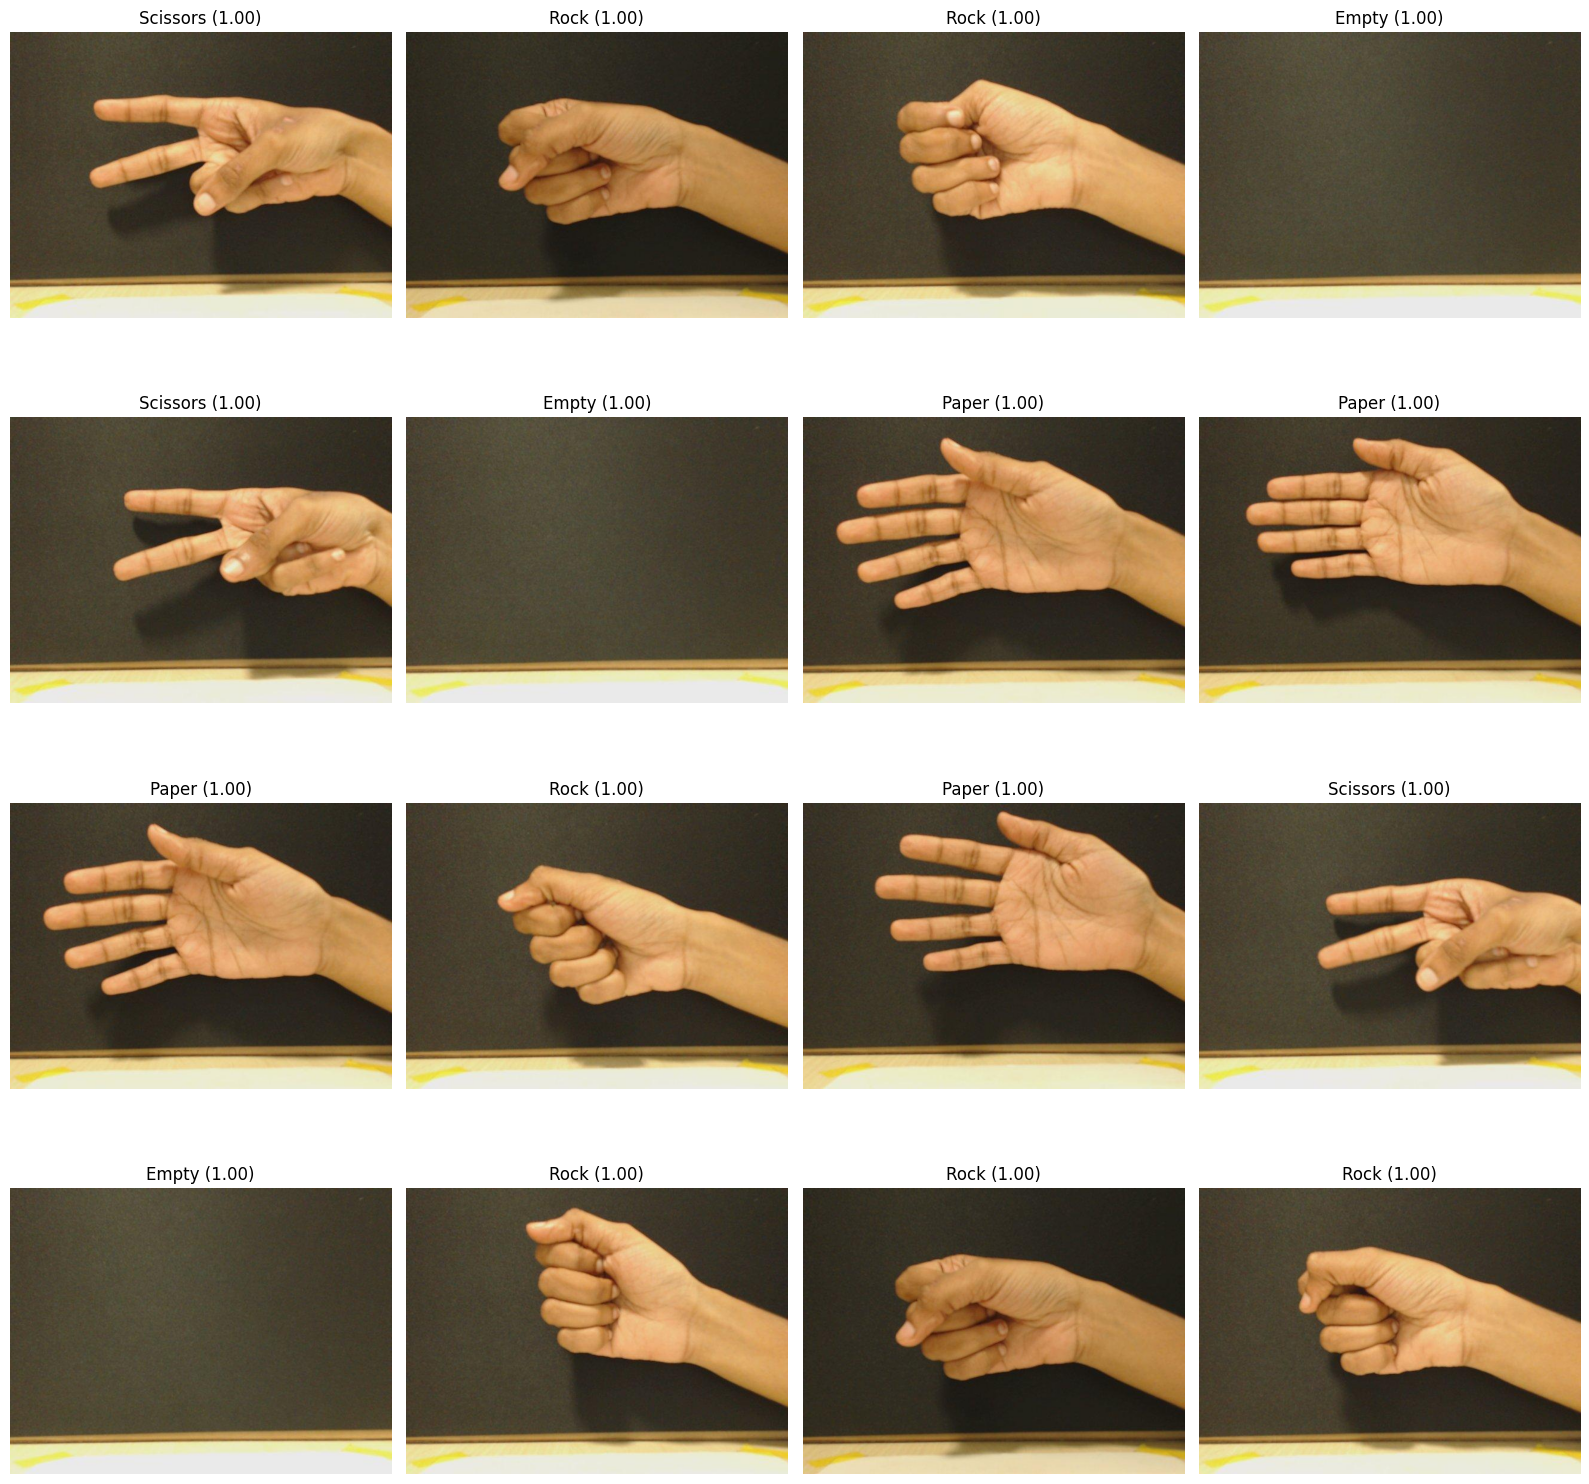

In [ ]:
import cv2
import os
import random
import matplotlib.pyplot as plt
#load traineed model
model = YOLO("/content/runs/classify/rock-paper-scissor-yolo/weights/best.pt")
#Test images directory
test_images_folder = "/content/rock-paper-scissor-dataset/test"
#image folders(rock,paper,scissors,empty)
image_folders = os.listdir(test_images_folder)
#plot settings
fig, ax = plt.subplots(4, 4, figsize = (16, 16))
ax = ax.ravel()

for idx in range(16):
  image_folder = random.choice(image_folders)
  image_files = os.listdir(os.path.join(test_images_folder, image_folder))
  image_path = os.path.join(test_images_folder, image_folder, random.choice(image_files))
  image = cv2.imread(image_path)

  #class inference
  result = model(image_path)[0]

  #get class name
  class_id = result.probs.top1   #probs obj stores results
  class_name = model.names[class_id]
  confidence = result.probs.top1conf.item()

  #convert BGR to RGB for plotting
  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  ax[idx].imshow(image_rgb)
  ax[idx].set_title(f"{class_name} ({confidence:.2f})", fontsize = 12)
  ax[idx].axis('off')

plt.tight_layout()
plt.show()